# Chaikin Money Flow — does accumulation/distribution lead price?
### Marc Chaikin's volume-flow oscillator, turned into a long/flat rule and raced honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads price%3F: Not_supported](https://img.shields.io/badge/Leads_price%3F-Not_supported-8b949e?style=flat-square)

Open any charting platform and you'll find Chaikin Money Flow (CMF) — a green/red oscillator that swings between −1 and +1. Above zero is 'accumulation' (smart money buying); below zero is 'distribution' (smart money selling). The promise: **money flow leads price** — so buy when CMF is green, step aside when it's red, and you'll be ahead of the move. We put that to the test on SPY.

> This is the plain-language layer. Want the HAC *t*-stats, the permutation placebo, and the benchmark race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chaikin_money_flow import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE", "GLD"]

def have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = have("SPY")

def load(t):
    b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]     # drop the in-progress last bar

print("real daily cache present (SPY):", HAVE_REAL)


real daily cache present (SPY): True


## The answer first

| Question | Answer |
|---|---|
| Does buying 'accumulation' beat holding SPY? | **No.** CMF long/flat nets a Sharpe of **-0.01**; just holding SPY nets **+0.51**. |
| Is the timing doing *anything*? | **No.** A permutation placebo that scrambles the signal's timing matches it exactly (p = **1.00**). |
| Is it better than a dumb 50/200 moving-average filter? | **No.** The SMA filter nets Sharpe **+0.68** — CMF trails it by **-0.69**. |
| Could you trade it? | **No.** Even before costs the edge is ~zero; costs only push it negative. |

> 'Money flow leads price' is a great story. On SPY it is indistinguishable from noise — and a plain moving-average crossover, which ignores volume entirely, wins.

## 1 · The claim

> *"Chaikin Money Flow reads where the close sits inside each bar's range and weights it by volume. Persistent buying near the highs on heavy volume (CMF > 0) is accumulation and precedes a rally; persistent selling near the lows (CMF < 0) is distribution and precedes a decline. Money flow leads price — so follow the flow."*

Marc Chaikin built the Accumulation/Distribution line in the 1970s and CMF on top of it. The idea is intuitive: if a stock keeps closing near its high on big volume, buyers are winning — and that pressure should show up in price *next*. We test whether 'green CMF = be long, red CMF = be flat' actually earns its keep on SPY.

## 2 · So what?

If CMF really *led* price, it would be a free lookahead: a daily, mechanical signal telling you to be in the market before the up-moves and out before the down-moves. Millions of retail traders read CMF exactly this way. If instead it merely *coincides* with price — confirming what already happened — then trading it adds turnover and cost without adding information, and a far simpler trend filter does better.

## 3 · How would we know?

One honest test:

1. **Turn CMF into a long/flat rule.** CMF(20) > 0 → be long SPY; CMF ≤ 0 → sit in cash. Decide at today's close, earn *tomorrow's* return (one execution lag).
2. **Race it — net of costs, excess-of-cash — against the obvious simpler rules:** a 50/200 SMA trend filter, a MACD filter, and plain buy-and-hold. If CMF's volume information helps, it should *beat* the volume-blind benchmarks.
3. **Scramble the timing.** A permutation placebo re-orders the signal in blocks. If the real strategy looks no different from the scramble, the timing is noise.

**What would make us say 'mirage':** a net Sharpe at or below the simpler benchmarks, a HAC *t* under 2, and a permutation *p* that doesn't reject the null.

## 4 · The teardown — what actually happens

**The race.** Four long/flat books on SPY, net of 2 bps one-way costs, excess-of-cash. If money flow leads price, the green bar should be tallest.

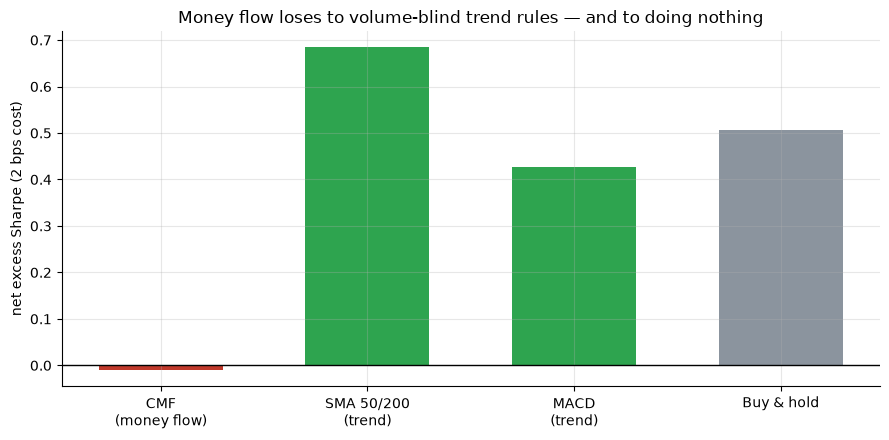

CMF -0.01  |  SMA +0.68  |  MACD +0.43  |  B&H +0.51


In [2]:
if HAVE_REAL:
    b = load('SPY')
    res = st.run_experiment(b, window=20, cmf_thr=0.0, cost_bps=2.0, perm_iter=2000)
    vals = [res['cmf']['net']['sharpe'], res['sma']['net']['sharpe'],
            res['macd']['net']['sharpe'], res['buy_hold']['net']['sharpe']]
else:
    vals = [-0.011, 0.684, 0.427, 0.505]
labels = ['CMF\n(money flow)', 'SMA 50/200\n(trend)', 'MACD\n(trend)', 'Buy & hold']
cols = [RED, GREEN, GREEN, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net excess Sharpe (2 bps cost)')
ax.set_title('Money flow loses to volume-blind trend rules — and to doing nothing')
plt.tight_layout(); plt.show()
print(f'CMF {vals[0]:+.2f}  |  SMA {vals[1]:+.2f}  |  MACD {vals[2]:+.2f}  |  B&H {vals[3]:+.2f}')

The CMF rule nets a Sharpe of **-0.01** — essentially zero. The dumb 50/200 moving-average filter, which never looks at volume at all, nets **+0.68**. Even *buy-and-hold* (+0.51) beats CMF. 'Money flow leads price' does not survive contact with the tape.

**Is the timing real or is it luck?** We scramble the CMF position in 21-day blocks 2,000 times and see where the real strategy lands in that placebo distribution.

In [3]:
if HAVE_REAL:
    perm = res['cmf']['perm']
    p = perm['p_value']; obs = perm['observed_mean']; plac = perm['placebo_mean']
else:
    p, obs, plac = 1.0, 0.0, 0.0003
print(f'observed mean daily edge: {obs:+.6f}')
print(f'placebo mean (scrambled): {plac:+.6f}')
print(f'permutation p-value: {p:.3f}  (>=0.05 means the timing is indistinguishable from noise)')

observed mean daily edge: +0.000013
placebo mean (scrambled): +0.000261
permutation p-value: 1.000  (>=0.05 means the timing is indistinguishable from noise)


The permutation *p* is **1.00** — the real CMF timing is no better than randomly shuffling when you're long. The signal carries no usable lead.

## 5 · The verdict

- **Signal — None.** CMF long/flat nets Sharpe **-0.01** on SPY, HAC *t* = **-0.06**; permutation *p* = **1.00**. Indistinguishable from noise.
- **Tradability — Mirage.** Even gross the edge is ~zero; costs make it negative. It loses to a volume-blind SMA filter and to buy-and-hold.
- **Does flow lead price? — Not supported.** The timing scramble matches the real signal; CMF coincides with price, it does not lead it.

## 6 · Could you actually trade it?

The CMF rule flips in and out of the market often, so costs bite. But the gross edge is already ~zero, so there's nothing for costs to eat into:

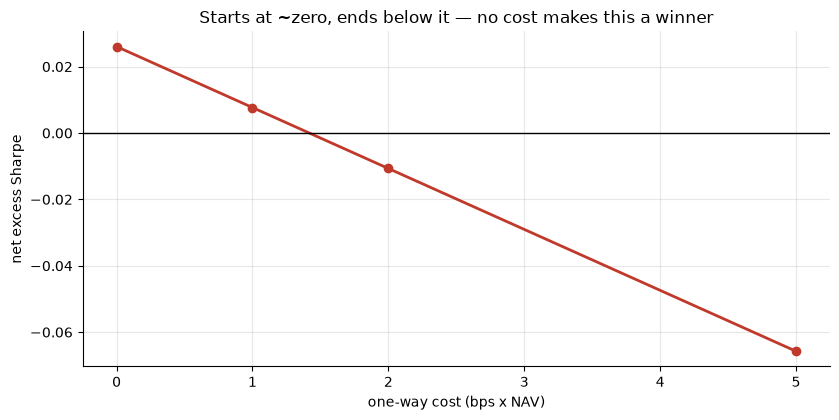

Gross Sharpe ~+0.03; the signal, not the cost, is the problem.


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    nets = []
    cmf = st.chaikin_money_flow(b, 20); pos = st.positions_from_cmf(cmf)
    for c in costs:
        bt = st.backtest(b, pos, cost_bps=c)
        nets.append(st.summarize_book(bt['net_excess'])['sharpe'])
else:
    nets = [0.026, 0.008, -0.011, -0.066]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps x NAV)'); ax.set_ylabel('net excess Sharpe')
ax.set_title('Starts at ~zero, ends below it — no cost makes this a winner')
plt.tight_layout(); plt.show()
print('Gross Sharpe ~+0.03; the signal, not the cost, is the problem.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real 'money-flow-leads-price' effect in a synthetic tape — and CMF *finds* it, beating buy-and-hold as the planted edge grows. The engine works; SPY just doesn't contain the effect.
- **Other tapes.** A few individual names (AAPL, GLD) show a positive CMF Sharpe — but they trended so hard that *their own* buy-and-hold beats CMF anyway. The flow isn't leading; the trend is.
- **The MFI cousin.** [Study 418](../../418-money-flow-index/) tests the Money Flow Index — the volume-weighted RSI — with the same harness and the same outcome.

*Think CMF leads price on a different asset or window? Fork this, swap the tape, and show a net excess Sharpe that beats the SMA filter *and* clears HAC t = 2. That's the bar.*